<a href="https://colab.research.google.com/github/saniya0210/Data_Science_Lab/blob/main/DS_E_7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S1 Import Required Libraries

In [ ]:
# Step 1: Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

#S2 Load the Dataset

In [ ]:
# (Download from Kaggle and upload CSV file in Colab/Jupyter)

# Step 2: Load Dataset
!unzip -o "/content/house .zip" # Unzip the dataset
df = pd.read_csv("HousingData.csv")   # change name if different or if the CSV is in a subdirectory

# Display first 5 rows
df.head()

Archive:  /content/house .zip
  inflating: HousingData.csv         


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,0.00632,18.0,2.31,0.0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0.0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0.0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0.0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0.0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,NaN,36.2


#S3 Understand the Dataset

In [ ]:
# Shape of dataset
print("Shape of dataset:", df.shape)

# Check data types
df.info()

# Check missing values
df.isnull().sum()

Shape of dataset: (506, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   CRIM     486 non-null    float64
 1   ZN       486 non-null    float64
 2   INDUS    486 non-null    float64
 3   CHAS     486 non-null    float64
 4   NOX      506 non-null    float64
 5   RM       506 non-null    float64
 6   AGE      486 non-null    float64
 7   DIS      506 non-null    float64
 8   RAD      506 non-null    int64  
 9   TAX      506 non-null    int64  
 10  PTRATIO  506 non-null    float64
 11  B        506 non-null    float64
 12  LSTAT    486 non-null    float64
 13  MEDV     506 non-null    float64
dtypes: float64(12), int64(2)
memory usage: 55.5 KB


,0
CRIM,20
ZN,20
INDUS,20
CHAS,20
NOX,0
RM,0
AGE,20
DIS,0
RAD,0
TAX,0


#S4  Handle Missing Values (If Any)

In [ ]:
# Fill missing values with column mean
df = df.fillna(df.mean())

# Verify again
df.isnull().sum()

,0
CRIM,0
ZN,0
INDUS,0
CHAS,0
NOX,0
RM,0
AGE,0
DIS,0
RAD,0
TAX,0


# S5 Exploratory Data Analysis (EDA)



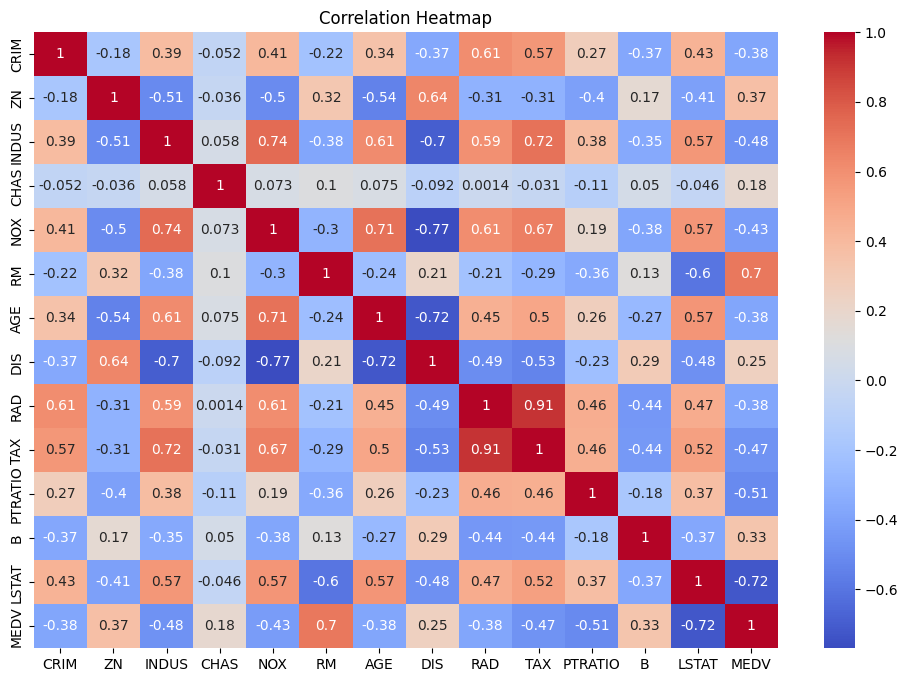

In [ ]:
# Statistical summary
df.describe()

# Correlation Heatmap

plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

# S6 Define Features (X) and Target (y)

In [ ]:
# Target variable = MEDV

X = df.drop("MEDV", axis=1)   # Features
y = df["MEDV"]                # Target

# S7 Split Data into Training and Testing Sets

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (404, 13)
Testing set size: (102, 13)


# S8 Train Linear Regression Model

In [ ]:
# Create model
model = LinearRegression()

# Train model
model.fit(X_train, y_train)

LinearRegression()

#S9  Model Coefficients

In [ ]:
# Intercept
print("Intercept:", model.intercept_)

# Coefficients
coeff_df = pd.DataFrame(model.coef_, X.columns, columns=["Coefficient"])
print(coeff_df)

Intercept: 27.912465201030926
         Coefficient
CRIM       -0.114140
ZN          0.029016
INDUS      -0.027133
CHAS        3.240673
NOX       -16.017543
RM          4.752410
AGE        -0.019520
DIS        -1.521593
RAD         0.222823
TAX        -0.009151
PTRATIO    -0.886045
B           0.012263
LSTAT      -0.438440


#S10  y_pred = model.predict(X_test)

In [ ]:
y_pred = model.predict(X_test)

# S11 Evaluate Model Performance

In [ ]:
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Squared Error: 25.01767202384268
Root Mean Squared Error: 5.0017668901941725
R2 Score: 0.6588520195508143


#S12 Compare Actual vs Predicted Values

In [ ]:
comparison = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

comparison.head(10)

,Actual Price,Predicted Price
173,23.6,29.143250
274,32.4,36.535668
491,13.6,14.492513
72,22.8,25.081110
452,16.1,18.456092
76,20.0,23.010494
316,17.8,18.138686
140,14.0,14.626517
471,19.6,22.115894
500,16.8,20.870636


#S13 Visualization (Actual vs Predicted)

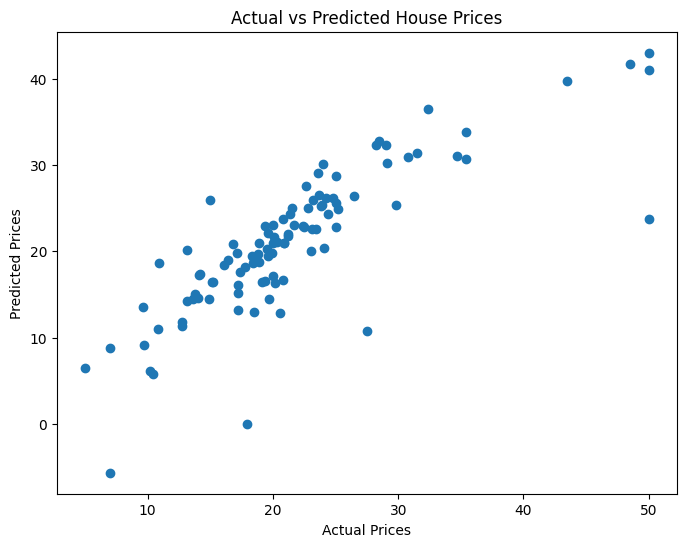

In [ ]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()